# Benchmark: TwINFER vs. GENIE3 / GRNBoost2 / PIDC / ppcor / rho against CollecTRI

Scores all 6 methods on all 9 gene sets against the same CollecTRI ground truth, on the same
edge universe, and reports AUPRC, F1, and EPR (Early Precision Ratio) -- plus a ratio-to-random
baseline for AUPRC and F1 (EPR is already, by definition, a ratio to random).

**Edge universe.** The competitor methods (`resources/networks/{method}_{gene_set}.csv`) only
ever score `TF -> target` pairs (source restricted to that gene set's own CollecTRI TFs, from
`resources/gene_sets_detail.json`; target ranges over the full panel). TwINFER's `ALL_PAIRS` run
(`resources/infer_results/{gene_set}_t2_t4_allpairs_50core/ranked_edges.csv`) explores the full
symmetric `n*(n-1)` directed universe, including non-TF sources -- so for a fair comparison every
method is restricted down to the **same** `TFs x panel` universe the competitors were structurally
limited to. A pair missing from a method's own output (rare -- GENIE3/GRNBoost2 drop
zero-importance edges) is filled with that method's minimum score, i.e. treated as its
least-confident call, not silently excluded from the universe.

**Ground truth.** CollecTRI edges (`resources/collectri_mouse.tsv`) intersected with the universe
above -- self-pairs stripped, same convention used throughout this project's gene-set-selection
notebook.

**Metrics** (`sklearn.metrics`, standard GRN-benchmark definitions -- BEELINE/Pratapa et al. 2020
for EPR specifically):
- **AUPRC** -- `average_precision_score(y_true, y_score)`, threshold-free.
- **F1** -- at the SAME fixed operating point EPR uses: top-`k` predictions, `k = |E_true|`. Note
  that at this specific `k` (equal to the positive count), precision@k, recall@k and F1@k are all
  numerically identical to each other -- and to `early_precision` below -- by construction, not by
  coincidence. It's reported as its own column because it was asked for explicitly, but it isn't
  telling you anything `early_precision`/`epr` don't already.
- **EPR (Early Precision Ratio)** -- take the top-`k` ranked predictions, `k = |E_true|` (the
  number of curated edges in this universe); `EarlyPrecision = TP@k / k`; the random-ranking
  expectation at that same `k` is the edge density `|E_true| / |universe|` (exact, from the
  hypergeometric mean); `EPR = EarlyPrecision / density`. EPR > 1 means the method beats random
  at recovering curated edges among its most-confident calls.

**Ratio to random** (AUPRC, F1 only -- EPR already is one). No closed form for the expected AUPRC
or F1@k under a random ranking, so both are estimated by Monte Carlo: reshuffle the observed
score column `N_RANDOM` times (the ground-truth labels and universe stay fixed -- only which pair
gets which score is randomized), recompute the metric each draw, and use the mean as the random
baseline. `f1_ratio` should land close to `epr` as a result (same reason `f1` equals
`early_precision`) -- a useful internal consistency check that the Monte Carlo procedure is
converging to the right place, since `epr`'s own baseline is computed exactly (not simulated).
Same convention `Transcriptomic Distance/helpers/benchmark_all.py` uses for its own
random-baseline rows (200 draws).

In [1]:
import json
import os

import numpy as np
import pandas as pd
from sklearn.metrics import average_precision_score, precision_recall_curve

HERE = "/home/gzu5140/TwINFER_KA/code/TwINFER/paper_analysis/larry_hematopoiesis_validation"
NETWORKS_DIR = os.path.join(HERE, "resources", "networks")
INFER_DIR = os.path.join(HERE, "resources", "infer_results")
COLLECTRI_PATH = os.path.join(HERE, "resources", "collectri_mouse.tsv")
GENE_SETS_PATH = os.path.join(HERE, "resources", "gene_sets.json")
GENE_SETS_DETAIL_PATH = os.path.join(HERE, "resources", "gene_sets_detail.json")
OUT_DIR = os.path.join(HERE, "resources", "benchmark")
os.makedirs(OUT_DIR, exist_ok=True)

GENE_SETS = ["variability_high", "variability_mid", "variability_low",
             "detection_high", "detection_mid", "detection_low",
             "correlation_high", "correlation_mid", "correlation_low"]
COMPETITOR_METHODS = ["rho", "ppcor", "pidc", "genie3", "grnboost2"]
ALL_METHODS = ["twinfer"] + COMPETITOR_METHODS

N_RANDOM = 200   # Monte Carlo draws for the AUPRC/F1 random baseline (matches benchmark_all.py)
SEED = 0
rng = np.random.default_rng(SEED)

## 1. Ground truth + per-gene-set universe

One universe per gene set: `TFs x panel` ordered pairs (self-pairs excluded) -- exactly what the
competitor CSVs already contain. `y_true` is the CollecTRI membership of each universe pair.

In [2]:
collectri = pd.read_csv(COLLECTRI_PATH, sep="\t")
collectri = collectri[collectri["source_genesymbol"] != collectri["target_genesymbol"]]
collectri_edges = set(zip(collectri["source_genesymbol"], collectri["target_genesymbol"]))
print(f"CollecTRI: {len(collectri_edges):,} directed edges (self-pairs stripped)")

gene_sets = json.load(open(GENE_SETS_PATH))
gene_sets_detail = json.load(open(GENE_SETS_DETAIL_PATH))


def build_universe(gene_set):
    """(TFs x panel, self-pairs excluded) for one gene set -- matches the competitor CSVs' own
    edge universe exactly, so every method is scored on identical ground."""
    criterion, level = gene_set.rsplit("_", 1)
    panel = gene_sets[gene_set]
    tfs = [tf for tf, _ in gene_sets_detail[criterion][level] if tf in panel]
    universe = [(a, b) for a in tfs for b in panel if a != b]
    y_true = np.array([1 if pair in collectri_edges else 0 for pair in universe], dtype=int)
    return universe, y_true, tfs


universes = {}
for gs in GENE_SETS:
    universe, y_true, tfs = build_universe(gs)
    universes[gs] = dict(universe=universe, y_true=y_true, tfs=tfs)
    print(f"{gs:<18} universe={len(universe):>5}  curated={int(y_true.sum()):>4}  "
          f"density={y_true.mean():.4f}  TFs={len(tfs)}")

CollecTRI: 39,520 directed edges (self-pairs stripped)
variability_high   universe=  645  curated= 101  density=0.1566  TFs=15
variability_mid    universe=  525  curated=  54  density=0.1029  TFs=15
variability_low    universe=  225  curated=  28  density=0.1244  TFs=9
detection_high     universe=  546  curated=  39  density=0.0714  TFs=14
detection_mid      universe=  462  curated=  51  density=0.1104  TFs=14
detection_low      universe=  645  curated=  67  density=0.1039  TFs=15
correlation_high   universe=  645  curated= 102  density=0.1581  TFs=15
correlation_mid    universe=  885  curated= 211  density=0.2384  TFs=15
correlation_low    universe=  408  curated=  88  density=0.2157  TFs=12


## 2. Load each method's scores, aligned to the universe

Every loader returns one `y_score` array in the exact same pair order as `universes[gene_set]["universe"]`.
A pair the method didn't emit is filled with that method's own minimum observed score (least
confident, not excluded).

In [3]:
def _align_scores(edge_score, universe):
    """edge_score: dict[(a,b)] -> float. Returns y_score in universe order, missing pairs filled
    with min(edge_score) (least confident -- the pair was never called, not tied for best)."""
    if not edge_score:
        return np.zeros(len(universe), dtype=float)
    floor = min(edge_score.values())
    return np.array([edge_score.get(pair, floor) for pair in universe], dtype=float)


def load_competitor(method, gene_set, universe):
    df = pd.read_csv(os.path.join(NETWORKS_DIR, f"{method}_{gene_set}.csv"))
    edge_score = {(r.TF, r.target): float(r.importance) for r in df.itertuples(index=False)}
    return _align_scores(edge_score, universe)


def load_twinfer(gene_set, universe, tfs):
    df = pd.read_csv(os.path.join(INFER_DIR, f"{gene_set}_t2_t4_allpairs_50core", "ranked_edges.csv"))
    tf_set = set(tfs)
    df = df[df["gene_1"].isin(tf_set) & (df["gene_1"] != df["gene_2"])]
    edge_score = {(r.gene_1, r.gene_2): float(r.twinScore) for r in df.itertuples(index=False)}
    return _align_scores(edge_score, universe)


scores = {}
for gs in GENE_SETS:
    universe = universes[gs]["universe"]
    tfs = universes[gs]["tfs"]
    scores[gs] = {"twinfer": load_twinfer(gs, universe, tfs)}
    for m in COMPETITOR_METHODS:
        scores[gs][m] = load_competitor(m, gs, universe)
    n_missing = {m: int((scores[gs][m] == scores[gs][m].min()).sum()) for m in ALL_METHODS}
    print(f"{gs:<18} loaded scores for {len(ALL_METHODS)} methods "
          f"(at-floor count, informational: {n_missing})")

variability_high   loaded scores for 6 methods (at-floor count, informational: {'twinfer': 9, 'rho': 1, 'ppcor': 1, 'pidc': 1, 'genie3': 1, 'grnboost2': 1})


variability_mid    loaded scores for 6 methods (at-floor count, informational: {'twinfer': 2, 'rho': 2, 'ppcor': 1, 'pidc': 1, 'genie3': 1, 'grnboost2': 1})
variability_low    loaded scores for 6 methods (at-floor count, informational: {'twinfer': 1, 'rho': 1, 'ppcor': 1, 'pidc': 1, 'genie3': 1, 'grnboost2': 1})


detection_high     loaded scores for 6 methods (at-floor count, informational: {'twinfer': 2, 'rho': 1, 'ppcor': 1, 'pidc': 1, 'genie3': 1, 'grnboost2': 1})


detection_mid      loaded scores for 6 methods (at-floor count, informational: {'twinfer': 1, 'rho': 1, 'ppcor': 1, 'pidc': 1, 'genie3': 1, 'grnboost2': 1})


detection_low      loaded scores for 6 methods (at-floor count, informational: {'twinfer': 2, 'rho': 1, 'ppcor': 1, 'pidc': 1, 'genie3': 1, 'grnboost2': 1})


correlation_high   loaded scores for 6 methods (at-floor count, informational: {'twinfer': 5, 'rho': 1, 'ppcor': 1, 'pidc': 1, 'genie3': 1, 'grnboost2': 1})


correlation_mid    loaded scores for 6 methods (at-floor count, informational: {'twinfer': 3, 'rho': 1, 'ppcor': 1, 'pidc': 1, 'genie3': 1, 'grnboost2': 1})


correlation_low    loaded scores for 6 methods (at-floor count, informational: {'twinfer': 2, 'rho': 1, 'ppcor': 1, 'pidc': 1, 'genie3': 1, 'grnboost2': 1})


## 3. Metrics: AUPRC, F1@k, EPR -- and the Monte Carlo random baseline

In [4]:
def f1_at_k(y_true, y_score):
    """F1 at the SAME fixed operating point EPR uses: top-k predictions, k = |E_true| (the number
    of curated edges in this universe). Note: when k equals the positive count, precision@k,
    recall@k, and F1@k are all numerically identical (a direct property of that choice of k) --
    so this will equal early_precision below. Reported anyway as its own column since it was asked
    for explicitly and it's still a meaningful, standard operating point (not derived from a
    threshold search like a curve-wide best-F1 would be)."""
    k = int(y_true.sum())
    n = len(y_true)
    if k == 0 or k >= n:
        return float("nan")
    top_k_idx = np.argsort(-y_score, kind="stable")[:k]
    tp = float(y_true[top_k_idx].sum())
    precision = tp / k
    recall = tp / k  # k == n_positives here, so recall@k == precision@k
    return 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0


def early_precision_ratio(y_true, y_score):
    """BEELINE-style EPR: top-k predictions (k = number of curated edges in this universe),
    precision there, divided by the random-ranking expectation at that k (= edge density, exact
    via the hypergeometric mean -- no Monte Carlo needed for this one)."""
    k = int(y_true.sum())
    n = len(y_true)
    if k == 0 or k >= n:
        return float("nan"), float("nan")
    top_k_idx = np.argsort(-y_score, kind="stable")[:k]
    early_precision = float(y_true[top_k_idx].sum()) / k
    density = k / n
    epr = early_precision / density if density > 0 else float("nan")
    return early_precision, epr


def observed_metrics(y_true, y_score):
    auprc = average_precision_score(y_true, y_score)
    f1 = f1_at_k(y_true, y_score)
    ep, epr = early_precision_ratio(y_true, y_score)
    return dict(auprc=auprc, f1=f1, early_precision=ep, epr=epr)


def random_baseline(y_true, y_score, n_random=N_RANDOM, seed=SEED):
    """Monte Carlo: reshuffle the SAME score values across the SAME universe n_random times (labels
    fixed), recompute AUPRC/F1@k each draw, return their means as the random-ranking expectation.
    EPR's random baseline is exact (see early_precision_ratio) and not reshuffled here -- F1@k's
    Monte Carlo mean should converge to the same density value, which is a useful internal
    consistency check (f1_ratio should land close to epr)."""
    local_rng = np.random.default_rng(seed)
    auprcs = np.empty(n_random)
    f1s = np.empty(n_random)
    for i in range(n_random):
        shuffled = local_rng.permutation(y_score)
        auprcs[i] = average_precision_score(y_true, shuffled)
        f1s[i] = f1_at_k(y_true, shuffled)
    return dict(auprc_random=float(auprcs.mean()), f1_random=float(f1s.mean()))


# smoke test: a perfect ranking should score AUPRC=1, EPR >> 1; a reversed ranking should score low
_yt = np.array([1, 1, 0, 0, 0])
_perfect = np.array([5, 4, 3, 2, 1])
_reversed = np.array([1, 2, 3, 4, 5])
print("perfect ranking:", observed_metrics(_yt, _perfect))
print("reversed ranking:", observed_metrics(_yt, _reversed))
assert observed_metrics(_yt, _perfect)["auprc"] == 1.0
assert observed_metrics(_yt, _perfect)["epr"] > observed_metrics(_yt, _reversed)["epr"]
assert observed_metrics(_yt, _perfect)["f1"] == observed_metrics(_yt, _perfect)["early_precision"]
print("OK")

perfect ranking: {'auprc': 1.0, 'f1': 1.0, 'early_precision': 1.0, 'epr': 2.5}
reversed ranking: {'auprc': 0.325, 'f1': 0.0, 'early_precision': 0.0, 'epr': 0.0}
OK


## 4. Run every (gene set, method) combination

In [5]:
rows = []
for gs in GENE_SETS:
    y_true = universes[gs]["y_true"]
    for method in ALL_METHODS:
        y_score = scores[gs][method]
        obs = observed_metrics(y_true, y_score)
        rnd = random_baseline(y_true, y_score, seed=SEED + hash((gs, method)) % (2**31))
        row = dict(
            gene_set=gs, method=method,
            n_universe=len(y_true), n_curated=int(y_true.sum()),
            auprc=obs["auprc"], auprc_random=rnd["auprc_random"],
            auprc_ratio=obs["auprc"] / rnd["auprc_random"] if rnd["auprc_random"] > 0 else float("nan"),
            f1=obs["f1"], f1_random=rnd["f1_random"],
            f1_ratio=obs["f1"] / rnd["f1_random"] if rnd["f1_random"] > 0 else float("nan"),
            early_precision=obs["early_precision"], epr=obs["epr"],
        )
        rows.append(row)
    print(f"{gs}: done")

results = pd.DataFrame(rows)
results.head(len(ALL_METHODS))

variability_high: done


variability_mid: done


variability_low: done


detection_high: done


detection_mid: done


detection_low: done


correlation_high: done


correlation_mid: done


correlation_low: done


,gene_set,method,n_universe,n_curated,auprc,auprc_random,auprc_ratio,f1,f1_random,f1_ratio,early_precision,epr
0,variability_high,twinfer,645,101,0.227114,0.164396,1.381507,0.237624,0.159010,1.494396,0.237624,1.517498
1,variability_high,rho,645,101,0.225730,0.165263,1.365882,0.207921,0.157970,1.316202,0.207921,1.327811
2,variability_high,ppcor,645,101,0.231336,0.164931,1.402616,0.237624,0.154851,1.534527,0.237624,1.517498
3,variability_high,pidc,645,101,0.198800,0.165006,1.204801,0.217822,0.155842,1.397713,0.217822,1.391040
4,variability_high,genie3,645,101,0.233126,0.164790,1.414686,0.297030,0.155446,1.910828,0.297030,1.896873
5,variability_high,grnboost2,645,101,0.210087,0.162933,1.289407,0.217822,0.154554,1.409353,0.217822,1.391040


## 5. Summary tables + save

In [6]:
out_path = os.path.join(OUT_DIR, "benchmark_results.csv")
results.to_csv(out_path, index=False)
print(f"wrote {out_path}  ({len(results)} rows)")

for metric, ratio_col in (("auprc", "auprc_ratio"), ("f1", "f1_ratio"), ("epr", None)):
    print(f"\n=== {metric} ===")
    pivot = results.pivot(index="gene_set", columns="method", values=metric)[ALL_METHODS]
    pivot = pivot.loc[GENE_SETS]
    display(pivot.round(3))
    if ratio_col:
        print(f"--- {ratio_col} (vs. that method's own random baseline) ---")
        pivot_r = results.pivot(index="gene_set", columns="method", values=ratio_col)[ALL_METHODS]
        pivot_r = pivot_r.loc[GENE_SETS]
        display(pivot_r.round(2))

print("\n=== mean across all 9 gene sets, per method ===")
summary = results.groupby("method")[["auprc", "auprc_ratio", "f1", "f1_ratio",
                                       "early_precision", "epr"]].mean()
display(summary.loc[ALL_METHODS].round(3))

summary_path = os.path.join(OUT_DIR, "benchmark_summary_by_method.csv")
summary.loc[ALL_METHODS].to_csv(summary_path)
print(f"wrote {summary_path}")

wrote /home/gzu5140/TwINFER_KA/code/TwINFER/paper_analysis/larry_hematopoiesis_validation/resources/benchmark/benchmark_results.csv  (54 rows)

=== auprc ===


method,twinfer,rho,ppcor,pidc,genie3,grnboost2
gene_set,,,,,,
variability_high,0.227,0.226,0.231,0.199,0.233,0.210
variability_mid,0.123,0.127,0.107,0.084,0.130,0.135
variability_low,0.145,0.165,0.156,0.110,0.171,0.169
detection_high,0.070,0.069,0.090,0.119,0.084,0.082
detection_mid,0.117,0.149,0.184,0.160,0.202,0.141
detection_low,0.130,0.154,0.129,0.108,0.114,0.134
correlation_high,0.223,0.241,0.193,0.242,0.177,0.229
correlation_mid,0.291,0.300,0.291,0.258,0.301,0.305
correlation_low,0.314,0.313,0.320,0.300,0.322,0.323


--- auprc_ratio (vs. that method's own random baseline) ---


method,twinfer,rho,ppcor,pidc,genie3,grnboost2
gene_set,,,,,,
variability_high,1.38,1.37,1.40,1.20,1.41,1.29
variability_mid,1.06,1.13,0.96,0.75,1.14,1.20
variability_low,1.01,1.16,1.08,0.74,1.19,1.16
detection_high,0.85,0.85,1.14,1.43,1.03,1.01
detection_mid,0.96,1.24,1.50,1.32,1.66,1.14
detection_low,1.17,1.38,1.15,0.95,1.02,1.19
correlation_high,1.34,1.46,1.16,1.45,1.07,1.38
correlation_mid,1.19,1.23,1.18,1.05,1.24,1.26
correlation_low,1.40,1.39,1.42,1.31,1.42,1.44



=== f1 ===


...


=== epr ===


method,twinfer,rho,ppcor,pidc,genie3,grnboost2
gene_set,,,,,,
variability_high,1.517,1.328,1.517,1.391,1.897,1.391
variability_mid,1.080,1.260,0.720,0.540,1.080,1.620
variability_low,1.148,0.861,1.148,0.287,1.435,1.148
detection_high,0.359,0.718,1.436,2.154,1.077,1.795
detection_mid,1.066,1.776,1.954,1.776,2.842,0.888
detection_low,1.293,1.149,1.006,0.575,1.293,1.293
correlation_high,1.488,1.860,1.178,1.612,1.178,1.612
correlation_mid,1.173,1.292,1.272,0.974,1.232,1.312
correlation_low,1.423,1.423,1.581,1.475,1.686,1.739



=== mean across all 9 gene sets, per method ===


,auprc,auprc_ratio,f1,f1_ratio,early_precision,epr
method,,,,,,
twinfer,0.182,1.152,0.177,1.174,0.177,1.172
rho,0.194,1.244,0.191,1.304,0.191,1.296
ppcor,0.189,1.222,0.190,1.309,0.190,1.312
pidc,0.175,1.134,0.169,1.182,0.169,1.198
genie3,0.193,1.244,0.217,1.531,0.217,1.524
grnboost2,0.192,1.229,0.203,1.417,0.203,1.422


wrote /home/gzu5140/TwINFER_KA/code/TwINFER/paper_analysis/larry_hematopoiesis_validation/resources/benchmark/benchmark_summary_by_method.csv


## 6. Heatmaps (EPR and AUPRC ratio, the two "beats random" views)

wrote /home/gzu5140/TwINFER_KA/code/TwINFER/paper_analysis/larry_hematopoiesis_validation/resources/benchmark/benchmark_heatmaps.pdf


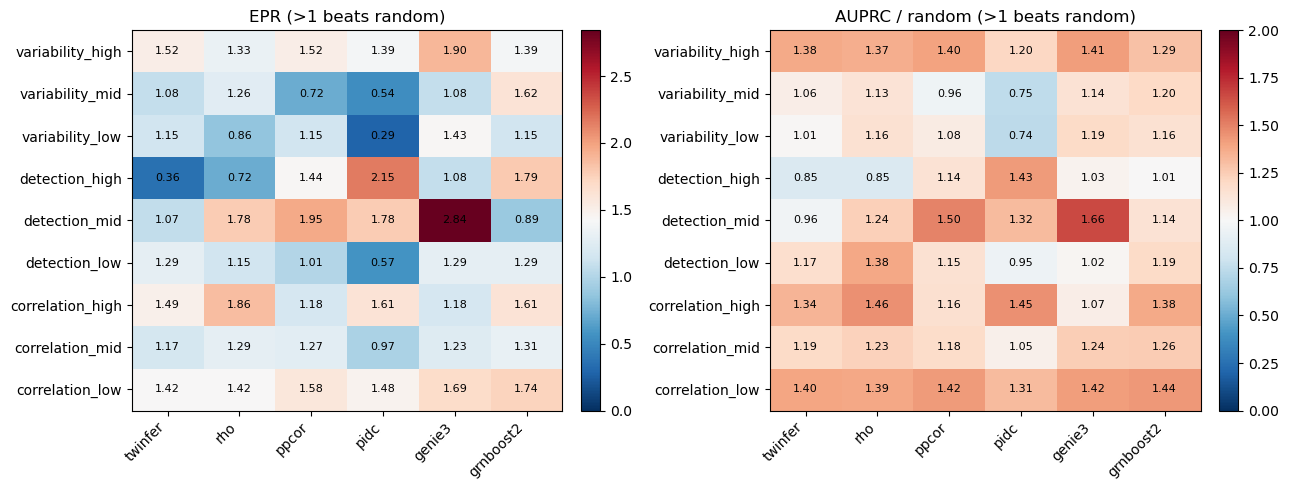

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, metric, title in zip(axes, ("epr", "auprc_ratio"), ("EPR", "AUPRC / random")):
    pivot = results.pivot(index="gene_set", columns="method", values=metric)[ALL_METHODS].loc[GENE_SETS]
    im = ax.imshow(pivot.to_numpy(), aspect="auto", cmap="RdBu_r",
                    vmin=0, vmax=max(2.0, float(np.nanmax(pivot.to_numpy()))))
    ax.set_xticks(range(len(ALL_METHODS)))
    ax.set_xticklabels(ALL_METHODS, rotation=45, ha="right")
    ax.set_yticks(range(len(GENE_SETS)))
    ax.set_yticklabels(GENE_SETS)
    ax.set_title(f"{title} (>1 beats random)")
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            v = pivot.to_numpy()[i, j]
            if np.isfinite(v):
                ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
fig_path = os.path.join(OUT_DIR, "benchmark_heatmaps.pdf")
plt.savefig(fig_path, bbox_inches="tight")
print(f"wrote {fig_path}")
plt.show()

## 7. New TwinScore (from `BEST_SCORER.md`)

A candidate replacement scoring formula, source:
`/gpfs/projects/b1255/yscher/Transcriptomic Distance/exports/twinscore_gated/BEST_SCORER.md`
(their "approved gzu functions" number for this formula: **3.98x base precision** on
`correlation_high`, NOT the struck/voided 5.10x, which came from an unapproved vendor-pinned
source per that file's own correction).

```
S(x->y) = z(|rho(t1)|) - z(|rho_hat_Delta(t1)|) - z(|rho(t2)-rho(t1)|)
          - z(|ref_Delta drift contrast|) - z(|gamma|) + 1/2 z*(z_Ddag)
          + (reg(x)-reg(y)) + CALL: +100 if |gated z_reg(t1)| > 1.645
```

Mapping to our own pipeline's quantities (confirmed/resolved with the user before implementing):
- `z(|rho(t1)|)`, `z(|rho(t2)-rho(t1)|)`, `z(|gamma|)` = our existing `z_abs_rho_t1`,
  `z_abs_rho_change`, `z_gamma` columns in `ranked_edges.csv` -- no new computation.
- `z_Ddag = z(gamma)` -- i.e. the SAME `z_gamma` column, used signed here (vs. `abs()`'d in the
  `-z(|gamma|)` term above) -- confirmed directly by the user, not inferred. Also resolves how
  `reg(g)` gets a natural direction: `z_gamma` is antisymmetric by construction
  (`gamma(x,y) = -gamma(y,x)`), so no artificial sign-flip convention is needed the way
  `twinscore_table.py`'s `zdd` dict needed one for a genuinely symmetric statistic.
- `reg(g)` = mean signed `z_gamma(g, w)` over every partner `w` TwINFER computed for `g` --
  computed from `ranked_edges.csv`'s own FULL native pair universe (all `n*(n-1)` pairs, not
  restricted to our TF x panel benchmarking universe), so "regulator-ness" reflects everything
  TwINFER knows about `g`, not just the subset we happen to be scoring below.
- `CALL: +100 if |gated z_reg(t1)| > 1.645` = our own `z_reg_gated`
  (`z_scores_by_step.json`), matched by sorted undirected pair.
- `z(|rho_hat_Delta(t1)|)` -- NOT directly saved. Built the same way `calculate_twin_score`
  builds `z_abs_rho_t1`/`t2`: null-unit `|twin_delta_t1|` against its own null
  (`raw_nulls.npz`'s `rho_delta_het_t1`, already saved), then panel-standardize across our
  universe's undirected pairs.
- `z(|ref_Delta drift contrast|)` -- `|random_delta_t2 - random_delta_t1|`, panel-standardized
  directly (no null-unit step -- matches `twinscore_table.py`'s own `DRIFT` construction exactly).
  `random_delta_t1`/`t2` were never saved by the original run (an omission caught mid-session);
  recomputed via `preprocessing/compute_random_delta_reference.py`, reusing
  `infer_with_twinfer`'s own default seed so the values match what that run would have produced.
- **Dropped, per explicit instruction**: `z(min(|rho_dagger_xy|,|rho_dagger_yx|))` -- would need a
  new permutation null we don't have cached; skipped rather than approximated.

**Scope**: `correlation_high` only for now -- it's the only gene set with the supplementary
`random_delta_t1`/`t2` matrices computed. Universe: our existing 645-pair `TFs x panel` set (kept,
per explicit instruction, so this stays comparable to the other 6 methods above rather than their
own 1892-pair full-panel universe).

In [8]:
NEW_SCORE_GENE_SET = "correlation_high"
GATED_CALL_THRESHOLD = 1.645


def _panel_z(values):
    """Matches calculate_twin_score's own _panel_z in correlation_functions.py exactly."""
    values = np.asarray(values, dtype=float)
    result = np.full(values.shape, np.nan, dtype=float)
    finite = np.isfinite(values)
    if not np.any(finite):
        return result
    x = values[finite]
    mu = float(np.mean(x))
    sd = float(np.std(x, ddof=0))
    if not np.isfinite(sd) or sd == 0:
        result[finite] = 0.0
    else:
        result[finite] = (x - mu) / sd
    return result


def _null_unit(observed, null_values, use_absolute=True):
    """Matches infer.py's own _null_unit exactly."""
    arr = np.asarray(null_values, dtype=float)
    arr = arr[np.isfinite(arr)]
    obs = float(observed)
    if use_absolute:
        obs = abs(obs)
        arr = np.abs(arr)
    if arr.size < 2:
        return np.nan
    mu = float(np.mean(arr))
    sd = float(np.std(arr, ddof=1))
    if not np.isfinite(sd) or sd <= 0:
        return np.nan
    return float((obs - mu) / sd)


gs = NEW_SCORE_GENE_SET
result_dir = os.path.join(INFER_DIR, f"{gs}_t2_t4_allpairs_50core")

ranked = pd.read_csv(os.path.join(result_dir, "ranked_edges.csv"))
twin_delta_t1 = pd.read_csv(os.path.join(result_dir, "corr_twin_delta_t1.csv"), index_col=0)
random_delta_t1 = pd.read_csv(os.path.join(result_dir, "corr_random_delta_t1.csv"), index_col=0)
random_delta_t2 = pd.read_csv(os.path.join(result_dir, "corr_random_delta_t2.csv"), index_col=0)
raw_nulls = np.load(os.path.join(result_dir, "raw_nulls.npz"))
z_scores_by_step = json.load(open(os.path.join(result_dir, "z_scores_by_step.json")))
z_reg_gated = z_scores_by_step["z_reg_gated"]

universe = universes[gs]["universe"]
undirected_pairs = sorted({tuple(sorted(p)) for p in universe})
print(f"{gs}: {len(universe)} directed pairs, {len(undirected_pairs)} undirected pairs "
      f"for panel standardization")

# ---- z(|rho_hat_Delta(t1)|)
u_abs_rho_delta_t1 = {}
for a, b in undirected_pairs:
    obs = twin_delta_t1.loc[a, b]
    null_key = f"rho_delta_het_t1__{a}__{b}"
    if null_key not in raw_nulls:
        null_key = f"rho_delta_het_t1__{b}__{a}"
    u_abs_rho_delta_t1[(a, b)] = (
        _null_unit(obs, raw_nulls[null_key], use_absolute=True) if null_key in raw_nulls else np.nan)

pairs_order = list(u_abs_rho_delta_t1.keys())
z_vals = _panel_z(np.array([u_abs_rho_delta_t1[p] for p in pairs_order]))
z_abs_rho_delta_t1 = dict(zip(pairs_order, z_vals))
n_missing_null = sum(1 for v in u_abs_rho_delta_t1.values() if not np.isfinite(v))
print(f"z(|rho_delta(t1)|): {n_missing_null}/{len(pairs_order)} pairs missing a matching saved "
      f"null (no Step-2 delta null was drawn for that pair in the ALL_PAIRS run -- left NaN, "
      f"excluded from panel_z's own mean/std, not treated as 0)")

# ---- z(|ref_Delta drift contrast|)
drift_raw = {(a, b): abs(float(random_delta_t2.loc[a, b]) - float(random_delta_t1.loc[a, b]))
             for a, b in undirected_pairs}
z_vals = _panel_z(np.array([drift_raw[p] for p in pairs_order]))
z_drift = dict(zip(pairs_order, z_vals))

print("undirected-pair terms built OK")

correlation_high: 645 directed pairs, 540 undirected pairs for panel standardization


z(|rho_delta(t1)|): 0/540 pairs missing a matching saved null (no Step-2 delta null was drawn for that pair in the ALL_PAIRS run -- left NaN, excluded from panel_z's own mean/std, not treated as 0)
undirected-pair terms built OK


In [9]:
def _lookup_undirected(d, a, b):
    return d.get((a, b), d.get((b, a), np.nan))


def _lookup_zreg_gated(a, b):
    for key in (f"{a}__{b}", f"{b}__{a}"):
        if key in z_reg_gated:
            return z_reg_gated[key]
    return np.nan


ranked_idx = ranked.set_index(["gene_1", "gene_2"])

# reg(g): mean SIGNED z_gamma(g, w) over every partner w TwINFER computed for g, from the FULL
# native pair set (not restricted to our benchmarking universe -- see markdown above).
z_gamma_by_pair = {(r.gene_1, r.gene_2): r.z_gamma for r in ranked.itertuples(index=False)}
all_genes = sorted({g for pair in z_gamma_by_pair for g in pair})
reg = {}
for g in all_genes:
    vals = [z_gamma_by_pair[(g, w)] for w in all_genes if w != g and (g, w) in z_gamma_by_pair]
    reg[g] = float(np.nanmean(vals)) if vals else np.nan

# A handful of universe pairs are absent from TwINFER's own ranked_edges.csv entirely -- even
# under ALL_PAIRS, some pairs never produce a usable classification (e.g. NaN correlation from
# near-constant expression). Confirmed by direct check: 10/645 pairs missing (5 undirected pairs,
# both directions) for correlation_high. These get an all-NaN score row, not a crash, and are
# floor-filled like any other missing-method pair when building y_score below.
missing_from_ranked = []

rows = []
for a, b in universe:
    if (a, b) not in ranked_idx.index:
        missing_from_ranked.append((a, b))
        rows.append(dict(gene_1=a, gene_2=b, new_twinscore=np.nan,
                          z_abs_rho_t1=np.nan, z_abs_rho_delta_t1=np.nan,
                          z_abs_rho_change=np.nan, z_drift=np.nan,
                          z_gamma=np.nan, reg_diff=np.nan, z_reg_gated=np.nan,
                          call_bonus=np.nan))
        continue
    row = ranked_idx.loc[(a, b)]
    z_abs_t1 = float(row["z_abs_rho_t1"])
    z_abs_change = float(row["z_abs_rho_change"])
    z_gamma_signed = float(row["z_gamma"])
    z_ddag = z_gamma_signed  # confirmed by the user: z_Ddag IS z(gamma)

    term_rho_delta = _lookup_undirected(z_abs_rho_delta_t1, a, b)
    term_drift = _lookup_undirected(z_drift, a, b)
    zg = _lookup_zreg_gated(a, b)
    call_bonus = 100.0 if (np.isfinite(zg) and abs(zg) > GATED_CALL_THRESHOLD) else 0.0
    reg_diff = reg.get(a, np.nan) - reg.get(b, np.nan)

    score = (z_abs_t1 - term_rho_delta - z_abs_change - term_drift
             - abs(z_gamma_signed) + 0.5 * z_ddag + reg_diff + call_bonus)
    rows.append(dict(gene_1=a, gene_2=b, new_twinscore=score,
                      z_abs_rho_t1=z_abs_t1, z_abs_rho_delta_t1=term_rho_delta,
                      z_abs_rho_change=z_abs_change, z_drift=term_drift,
                      z_gamma=z_gamma_signed, reg_diff=reg_diff, z_reg_gated=zg,
                      call_bonus=call_bonus))

new_score_df = pd.DataFrame(rows)
n_nan = int(new_score_df["new_twinscore"].isna().sum())
print(f"{gs}: {len(new_score_df)} scored pairs, "
      f"{int((new_score_df['call_bonus'] > 0).sum())} called "
      f"(|z_reg_gated|>{GATED_CALL_THRESHOLD})")
print(f"{len(missing_from_ranked)} pairs entirely absent from TwINFER's ranked_edges.csv "
      f"(not classifiable, not just missing a null): {missing_from_ranked}")
print(f"{n_nan} total NaN-score pairs -- floor-filled (least confident) before benchmarking, "
      f"not excluded from the universe")
new_score_df.sort_values("new_twinscore", ascending=False).head(10)

correlation_high: 645 scored pairs, 478 called (|z_reg_gated|>1.645)
4 pairs entirely absent from TwINFER's ranked_edges.csv (not classifiable, not just missing a null): [('Bcl11a', 'Npm1'), ('Cebpb', 'Cybb'), ('Jun', 'Cybb'), ('Npm1', 'Bcl11a')]
4 total NaN-score pairs -- floor-filled (least confident) before benchmarking, not excluded from the universe


,gene_1,gene_2,new_twinscore,z_abs_rho_t1,z_abs_rho_delta_t1,z_abs_rho_change,z_drift,z_gamma,reg_diff,z_reg_gated,call_bonus
296,Npm1,Srm,108.040293,4.087675,-3.430981,-0.890387,-0.479280,-0.466206,-0.148719,11.840361,100.0
587,Lmo2,Npm1,107.548612,3.276625,-2.502075,-1.058453,-1.027868,0.368464,-0.132177,10.901561,100.0
284,Npm1,Lmo2,107.444502,3.276625,-2.502075,-1.058453,-1.027868,-0.368464,0.132177,10.901561,100.0
262,Npm1,Cd34,106.098006,2.861233,-0.825020,-1.085480,-1.128281,1.314871,0.855428,14.173927,100.0
285,Npm1,Myc,106.097572,3.368423,-3.241687,0.244856,-0.373431,2.043094,0.380434,9.713986,100.0
274,Npm1,Gapdh,105.928626,6.534288,-1.178698,0.399954,1.162608,-0.143547,-0.006476,23.249097,100.0
585,Lmo2,Myc,105.669001,1.788473,-2.067529,-0.894547,-1.111649,-0.294302,0.248257,4.881951,100.0
542,Myc,Lmo2,105.466790,1.788473,-2.067529,-0.894547,-1.111649,0.294302,-0.248257,4.881951,100.0
554,Myc,Srm,105.172565,1.896212,-3.541528,-0.716055,-0.884617,-0.891130,-0.529153,3.546699,100.0
298,Npm1,Tfec,104.696777,1.692771,-1.759754,-0.892681,-1.062014,1.221144,-0.099870,6.008250,100.0


In [10]:
edge_score_new = {(r.gene_1, r.gene_2): r.new_twinscore for r in new_score_df.itertuples(index=False)
                  if np.isfinite(r.new_twinscore)}
y_score_new = _align_scores(edge_score_new, universe)

y_true_gs = universes[gs]["y_true"]
obs_new = observed_metrics(y_true_gs, y_score_new)
rnd_new = random_baseline(y_true_gs, y_score_new, seed=SEED + 999)

print(f"new TwinScore on {gs}:")
print(f"  AUPRC = {obs_new['auprc']:.3f}  (ratio {obs_new['auprc'] / rnd_new['auprc_random']:.2f})")
print(f"  F1@k  = {obs_new['f1']:.3f}  (ratio {obs_new['f1'] / rnd_new['f1_random']:.2f})")
print(f"  EPR   = {obs_new['epr']:.3f}  (early_precision = {obs_new['early_precision']:.3f})")
print(f"\n  For reference, BEST_SCORER.md's own reported 'approved gzu functions' number for "
      f"this exact formula on correlation_high: 3.98x base precision (their own x-base metric, "
      f"not identical in construction to our EPR/AUPRC-ratio, so treat as a ballpark check, not "
      f"an exact-match target).")

comp = results[results["gene_set"] == gs][["method", "auprc", "auprc_ratio", "f1", "f1_ratio", "epr"]].copy()
comp = pd.concat([comp, pd.DataFrame([dict(
    method="new_twinscore", auprc=obs_new["auprc"], auprc_ratio=obs_new["auprc"] / rnd_new["auprc_random"],
    f1=obs_new["f1"], f1_ratio=obs_new["f1"] / rnd_new["f1_random"], epr=obs_new["epr"])])],
    ignore_index=True)
comp = comp.sort_values("epr", ascending=False).reset_index(drop=True)
comp.round(3)

new TwinScore on correlation_high:
  AUPRC = 0.163  (ratio 0.99)
  F1@k  = 0.157  (ratio 1.00)
  EPR   = 0.992  (early_precision = 0.157)

  For reference, BEST_SCORER.md's own reported 'approved gzu functions' number for this exact formula on correlation_high: 3.98x base precision (their own x-base metric, not identical in construction to our EPR/AUPRC-ratio, so treat as a ballpark check, not an exact-match target).


,method,auprc,auprc_ratio,f1,f1_ratio,epr
0,rho,0.241,1.457,0.294,1.870,1.860
1,grnboost2,0.229,1.378,0.255,1.585,1.612
2,pidc,0.242,1.454,0.255,1.612,1.612
3,twinfer,0.223,1.342,0.235,1.513,1.488
4,ppcor,0.193,1.161,0.186,1.174,1.178
5,genie3,0.177,1.069,0.186,1.178,1.178
6,new_twinscore,0.163,0.991,0.157,1.000,0.992


## 8. SYM TwinScore (`helpers/twinscore_table.py`'s `SYM` component)

A different, simpler formula found by request in the same `Transcriptomic Distance` codebase --
`helpers/twinscore_table.py`'s `score()` function builds this as its symmetric ("does this pair
look like a real edge at all") component, `SYM`:

```
SYM(x,y) = s(min(zr1, zr2)) - s(|CHv|) - s(DRIFT) - s(INH) + s(GAM)
```
where `zr1,zr2 = |z_rho(t1)|,|z_rho(t2)|`, `CHv = z_change`, `DRIFT = |ref_t2-ref_t1|`,
`INH = min(|z_rho_dagger_x->y|, |z_rho_dagger_y->x|)`, `GAM = z_gamma`.

**Every one of these five raw quantities is already saved** -- no new computation needed this time:
- `zr1, zr2` -> our `u_abs_rho_t1`, `u_abs_rho_t2` (`ranked_edges.csv`) -- confirmed symmetric
  across direction (same value for (a,b) and (b,a)), matching that these describe an undirected
  gene-gene relationship.
- `CHv` (already abs'd here since their file wraps it again in `s(|CHv|)` -- ours is stored
  pre-abs'd already) -> `u_abs_rho_change` -- also confirmed symmetric across direction.
- `DRIFT` -> `|random_delta_t2 - random_delta_t1|`, from the supplementary
  `corr_random_delta_t1/t2.csv` computed for Section 7.
- `INH` -> `min(|direction_z_scores[(x,y)]|, |direction_z_scores[(y,x)]|)` --
  `z_scores_by_step.json`'s `direction_z_scores` IS `z_rho_dagger` per ordered pair (the direction
  step's own z-score, `identify_actual_directed_edges`'s `z_rho_cross`) -- this is the term
  Section 7 dropped for lack of a saved null, but it turns out no new null is needed: the
  DIRECTED z-score itself (not the raw null array) is exactly what `INH` wants.
- `GAM` -> `u_gamma` -- confirmed ANTIsymmetric across direction (flips sign), so this is the one
  term that can actually carry orientation. Following what was literally asked
  (`+ s(z_gamma)`, signed) rather than `twinscore_table.py`'s own `+s(|GAM|)` -- their file adds
  `|GAM|` to `SYM` (a magnitude-only, undirected term) and handles orientation entirely through a
  SEPARATE `ANTI = 0.5*s(z_Ddag)` term added afterward with `sign(gamma)`, which was not asked
  for here. Using the signed value directly means THIS term is `SYM`'s only source of direction.

**Standardization**: `s()` exactly as found (`ddof=1` sample std, NaNs filled to
`min(standardized values) - 1` rather than 0 or the mean), applied across our own 645-pair
benchmarking universe directly (all 645 directed rows, not deduplicated to undirected pairs --
matches how their own file standardizes across its full ordered-pair list).

**Filter (added after re-checking their actual `score()` function)**: a pair must pass BOTH
`existence` (`|z_rho(t1)| > 2.576` OR `|z_rho(t2)| > 2.576`, using our `u_abs_rho_t1`/`t2` as the
`z_rho` proxy) and `regulation` (`|z_reg_gated| > 1.645`) to get a real `SYM` score; a pair failing
either is scored `-1e12` (ranked below everything that passes), matching
`PASS = defined & ((zr1>2.576)|(zr2>2.576)) & (|GZ|>1.645)` in their file exactly. Originally
omitted -- this notebook's first pass at SYM scored every pair continuously with no gate at all.

In [11]:
def s(v):
    """Exactly as found in helpers/twinscore_table.py: sample std (ddof=1), NaNs filled to
    min(standardized values) - 1, not 0 or the mean."""
    v = np.asarray(v, dtype=float)
    f = np.isfinite(v)
    o = (v - np.nanmean(v)) / max(np.nanstd(v, ddof=1), 1e-12)
    return np.where(f, o, np.nanmin(o[f]) - 1.0)


direction_z_scores = z_scores_by_step["direction_z_scores"]  # already loaded in Section 7


def _lookup_direction_z(a, b):
    return direction_z_scores.get(f"{a}__{b}", np.nan)


ranked_u = ranked.set_index(["gene_1", "gene_2"])

zr1, zr2, ch_abs, drift_vals, inh_vals, gam_signed = [], [], [], [], [], []
for a, b in universe:
    if (a, b) not in ranked_u.index:
        zr1.append(np.nan); zr2.append(np.nan); ch_abs.append(np.nan)
        drift_vals.append(np.nan); inh_vals.append(np.nan); gam_signed.append(np.nan)
        continue
    row = ranked_u.loc[(a, b)]
    zr1.append(float(row["u_abs_rho_t1"]))
    zr2.append(float(row["u_abs_rho_t2"]))
    ch_abs.append(float(row["u_abs_rho_change"]))
    drift_vals.append(_lookup_undirected(drift_raw, a, b))
    z_xy = _lookup_direction_z(a, b)
    z_yx = _lookup_direction_z(b, a)
    inh_vals.append(np.nanmin([abs(z_xy) if np.isfinite(z_xy) else np.nan,
                                abs(z_yx) if np.isfinite(z_yx) else np.nan]))
    gam_signed.append(float(row["u_gamma"]))

zr1, zr2 = np.array(zr1), np.array(zr2)
min_zr = np.minimum(zr1, zr2)
ch_abs = np.array(ch_abs)
drift_vals = np.array(drift_vals)
inh_vals = np.array(inh_vals)
gam_signed = np.array(gam_signed)

zreg_vals = np.array([_lookup_zreg_gated(a, b) for a, b in universe])
defined = np.isfinite(zr1) & np.isfinite(zr2) & np.isfinite(zreg_vals)
existence_pass = (zr1 > 2.576) | (zr2 > 2.576)
regulation_pass = np.abs(zreg_vals) > 1.645
PASS = defined & existence_pass & regulation_pass

sym_score_raw = s(min_zr) - s(ch_abs) - s(drift_vals) - s(inh_vals) + s(gam_signed)
sym_score = np.where(PASS, sym_score_raw, -1e12)

n_nan_inh = int(np.sum(~np.isfinite(inh_vals)))
print(f"{gs}: SYM computed for {len(universe)} pairs "
      f"({n_nan_inh} with a missing INH -- no direction_z_score for one or both orderings, "
      f"filled via s()'s own min-1 rule)")
print(f"filter (twinscore_table.py's own PASS gate): {int(PASS.sum())}/{len(universe)} pairs pass "
      f"(existence: |z_rho_t1| or |z_rho_t2| > 2.576; regulation: |z_reg_gated| > 1.645) -- "
      f"failing pairs scored -1e12, ranked below everything that passes")

sym_df = pd.DataFrame({"gene_1": [p[0] for p in universe], "gene_2": [p[1] for p in universe],
                        "sym_twinscore": sym_score, "min_zr": min_zr, "ch_abs": ch_abs,
                        "drift": drift_vals, "inh": inh_vals, "gamma_signed": gam_signed})
sym_df.sort_values("sym_twinscore", ascending=False).head(10)

correlation_high: SYM computed for 645 pairs (4 with a missing INH -- no direction_z_score for one or both orderings, filled via s()'s own min-1 rule)
filter (twinscore_table.py's own PASS gate): 433/645 pairs pass (existence: |z_rho_t1| or |z_rho_t2| > 2.576; regulation: |z_reg_gated| > 1.645) -- failing pairs scored -1e12, ranked below everything that passes


,gene_1,gene_2,sym_twinscore,min_zr,ch_abs,drift,inh,gamma_signed
398,Tfec,Elane,8.434132,23.507625,0.142613,0.032908,0.395390,7.628664
587,Lmo2,Npm1,6.833630,33.298389,-1.233000,0.005011,0.378798,0.671705
285,Npm1,Myc,6.809274,34.016695,3.024663,0.035645,0.204809,3.724536
294,Npm1,Sox4,6.401655,14.216409,-1.231768,0.011017,0.033931,3.938496
403,Tfec,Gapdh,6.143757,24.439690,2.961468,0.045297,0.194999,5.180771
284,Npm1,Lmo2,6.044299,33.298389,-1.233000,0.005011,0.378798,-0.671705
298,Npm1,Tfec,5.945148,20.905021,-0.691452,0.003413,0.313613,2.226131
262,Npm1,Cd34,5.273972,30.048024,-1.321293,0.000311,2.082881,2.396995
67,Cebpd,Lgals1,5.205546,15.995430,-1.297433,0.008923,0.010520,1.308270
203,Gata2,Plek,5.090430,7.710607,-0.549202,0.022025,0.064977,4.144522


In [12]:
edge_score_sym = {(r.gene_1, r.gene_2): r.sym_twinscore for r in sym_df.itertuples(index=False)
                  if np.isfinite(r.sym_twinscore)}
y_score_sym = _align_scores(edge_score_sym, universe)

obs_sym = observed_metrics(y_true_gs, y_score_sym)
rnd_sym = random_baseline(y_true_gs, y_score_sym, seed=SEED + 4242)

print(f"SYM TwinScore on {gs}:")
print(f"  AUPRC = {obs_sym['auprc']:.3f}  (ratio {obs_sym['auprc'] / rnd_sym['auprc_random']:.2f})")
print(f"  F1@k  = {obs_sym['f1']:.3f}  (ratio {obs_sym['f1'] / rnd_sym['f1_random']:.2f})")
print(f"  EPR   = {obs_sym['epr']:.3f}  (early_precision = {obs_sym['early_precision']:.3f})")

comp2 = comp.copy()
comp2 = pd.concat([comp2, pd.DataFrame([dict(
    method="sym_twinscore", auprc=obs_sym["auprc"], auprc_ratio=obs_sym["auprc"] / rnd_sym["auprc_random"],
    f1=obs_sym["f1"], f1_ratio=obs_sym["f1"] / rnd_sym["f1_random"], epr=obs_sym["epr"])])],
    ignore_index=True)
comp2 = comp2.sort_values("epr", ascending=False).reset_index(drop=True)
comp2.round(3)

SYM TwinScore on correlation_high:
  AUPRC = 0.160  (ratio 0.97)
  F1@k  = 0.137  (ratio 0.88)
  EPR   = 0.868  (early_precision = 0.137)


,method,auprc,auprc_ratio,f1,f1_ratio,epr
0,rho,0.241,1.457,0.294,1.870,1.860
1,grnboost2,0.229,1.378,0.255,1.585,1.612
2,pidc,0.242,1.454,0.255,1.612,1.612
3,twinfer,0.223,1.342,0.235,1.513,1.488
4,ppcor,0.193,1.161,0.186,1.174,1.178
5,genie3,0.177,1.069,0.186,1.178,1.178
6,new_twinscore,0.163,0.991,0.157,1.000,0.992
7,sym_twinscore,0.160,0.965,0.137,0.877,0.868


## 9. Full universe: all genes -> all genes (not just TFs), all 9 gene sets, all 6 methods

Same 6 methods as Sections 1-6, same metrics, but the universe is now every ordered pair among a
gene set's own panel genes (`n*(n-1)`, e.g. 1892 for `correlation_high`'s 44 genes) -- not
restricted to CollecTRI TFs as sources. The 5 competitors were rerun with `ALL_GENES=1`
(`resources/networks/{method}_{gene_set}_allgenes.csv`); TwINFER's `ranked_edges.csv` was already
the full universe natively, so it needs no rerun, just no TF filter this time.

In [13]:
def build_universe_allgenes(gene_set):
    panel = gene_sets[gene_set]
    universe = [(a, b) for a in panel for b in panel if a != b]
    y_true = np.array([1 if pair in collectri_edges else 0 for pair in universe], dtype=int)
    return universe, y_true


universes_allgenes = {}
for gene_set in GENE_SETS:
    universe, y_true = build_universe_allgenes(gene_set)
    universes_allgenes[gene_set] = dict(universe=universe, y_true=y_true)
    print(f"{gene_set:<18} universe={len(universe):>5}  curated={int(y_true.sum()):>4}  "
          f"density={y_true.mean():.4f}")


def load_competitor_allgenes(method, gene_set, universe):
    df = pd.read_csv(os.path.join(NETWORKS_DIR, f"{method}_{gene_set}_allgenes.csv"))
    edge_score = {(r.TF, r.target): float(r.importance) for r in df.itertuples(index=False)}
    return _align_scores(edge_score, universe)


def load_twinfer_allgenes(gene_set, universe):
    df = pd.read_csv(os.path.join(INFER_DIR, f"{gene_set}_t2_t4_allpairs_50core", "ranked_edges.csv"))
    edge_score = {(r.gene_1, r.gene_2): float(r.twinScore) for r in df.itertuples(index=False)}
    return _align_scores(edge_score, universe)


scores_allgenes = {}
for gene_set in GENE_SETS:
    universe = universes_allgenes[gene_set]["universe"]
    scores_allgenes[gene_set] = {"twinfer": load_twinfer_allgenes(gene_set, universe)}
    for m in COMPETITOR_METHODS:
        scores_allgenes[gene_set][m] = load_competitor_allgenes(m, gene_set, universe)
    print(f"{gene_set:<18} loaded scores for {len(ALL_METHODS)} methods")

variability_high   universe= 1892  curated= 101  density=0.0534
variability_mid    universe= 1260  curated=  57  density=0.0452
variability_low    universe=  650  curated=  28  density=0.0431
detection_high     universe= 1560  curated=  39  density=0.0250
detection_mid      universe= 1122  curated=  51  density=0.0455
detection_low      universe= 1892  curated=  72  density=0.0381
correlation_high   universe= 1892  curated= 122  density=0.0645
correlation_mid    universe= 3540  curated= 225  density=0.0636
correlation_low    universe= 1190  curated=  89  density=0.0748


variability_high   loaded scores for 6 methods


variability_mid    loaded scores for 6 methods
variability_low    loaded scores for 6 methods


detection_high     loaded scores for 6 methods


detection_mid      loaded scores for 6 methods
detection_low      loaded scores for 6 methods


correlation_high   loaded scores for 6 methods


correlation_mid    loaded scores for 6 methods


correlation_low    loaded scores for 6 methods


In [14]:
rows_ag = []
for gene_set in GENE_SETS:
    y_true = universes_allgenes[gene_set]["y_true"]
    for method in ALL_METHODS:
        y_score = scores_allgenes[gene_set][method]
        obs = observed_metrics(y_true, y_score)
        rnd = random_baseline(y_true, y_score, seed=SEED + hash((gene_set, method, "allgenes")) % (2**31))
        rows_ag.append(dict(
            gene_set=gene_set, method=method,
            n_universe=len(y_true), n_curated=int(y_true.sum()),
            auprc=obs["auprc"], auprc_random=rnd["auprc_random"],
            auprc_ratio=obs["auprc"] / rnd["auprc_random"] if rnd["auprc_random"] > 0 else float("nan"),
            f1=obs["f1"], f1_random=rnd["f1_random"],
            f1_ratio=obs["f1"] / rnd["f1_random"] if rnd["f1_random"] > 0 else float("nan"),
            early_precision=obs["early_precision"], epr=obs["epr"],
        ))
    print(f"{gene_set}: done")

results_allgenes = pd.DataFrame(rows_ag)
out_path = os.path.join(OUT_DIR, "benchmark_results_allgenes.csv")
results_allgenes.to_csv(out_path, index=False)
print(f"wrote {out_path}  ({len(results_allgenes)} rows)")

print("\n=== epr (all-genes-to-all-genes universe) ===")
pivot = results_allgenes.pivot(index="gene_set", columns="method", values="epr")[ALL_METHODS].loc[GENE_SETS]
display(pivot.round(3))

print("\n=== mean across all 9 gene sets, per method (all-genes universe) ===")
summary_ag = results_allgenes.groupby("method")[["auprc", "auprc_ratio", "f1", "f1_ratio",
                                                    "early_precision", "epr"]].mean()
summary_ag = summary_ag.loc[ALL_METHODS]
display(summary_ag.round(3))

summary_ag_path = os.path.join(OUT_DIR, "benchmark_summary_by_method_allgenes.csv")
summary_ag.to_csv(summary_ag_path)
print(f"wrote {summary_ag_path}")

print("\n=== side by side: TF-restricted (Section 5) vs all-genes (Section 9) mean EPR ===")
side = pd.DataFrame({"epr_tf_restricted": summary.loc[ALL_METHODS, "epr"],
                      "epr_all_genes": summary_ag.loc[ALL_METHODS, "epr"]})
display(side.round(3))

variability_high: done


variability_mid: done


variability_low: done


detection_high: done


detection_mid: done


...

method,twinfer,rho,ppcor,pidc,genie3,grnboost2
gene_set,,,,,,
variability_high,1.298,1.113,1.669,2.226,0.927,1.113
variability_mid,0.388,1.163,0.388,0.388,1.939,1.163
variability_low,0.000,0.000,0.829,0.829,0.000,0.000
detection_high,0.000,2.051,2.051,2.051,2.051,1.026
detection_mid,1.294,1.294,2.157,1.294,1.294,0.000
detection_low,1.095,1.460,1.460,0.000,1.460,1.460
correlation_high,1.144,0.890,0.890,1.653,0.000,0.254
correlation_mid,1.189,1.259,1.119,1.329,0.909,0.839
correlation_low,1.352,0.901,1.202,1.953,0.451,1.202



=== mean across all 9 gene sets, per method (all-genes universe) ===


,auprc,auprc_ratio,f1,f1_ratio,early_precision,epr
method,,,,,,
twinfer,0.059,1.040,0.049,0.870,0.049,0.862
rho,0.059,1.089,0.054,1.119,0.054,1.126
ppcor,0.060,1.076,0.063,1.298,0.063,1.307
pidc,0.065,1.155,0.069,1.292,0.069,1.302
genie3,0.056,1.043,0.044,0.986,0.044,1.003
grnboost2,0.053,0.955,0.039,0.777,0.039,0.784


wrote /home/gzu5140/TwINFER_KA/code/TwINFER/paper_analysis/larry_hematopoiesis_validation/resources/benchmark/benchmark_summary_by_method_allgenes.csv

=== side by side: TF-restricted (Section 5) vs all-genes (Section 9) mean EPR ===


,epr_tf_restricted,epr_all_genes
method,,
twinfer,1.172,0.862
rho,1.296,1.126
ppcor,1.312,1.307
pidc,1.198,1.302
genie3,1.524,1.003
grnboost2,1.422,0.784


## 10. SYM TwinScore as the "twinfer" method, all 9 gene sets, full all-genes universe

Per instruction: use Section 8's `sym_twinscore` (`twinscore_table.py`'s SYM formula) as THE
TwinScore representative from here on, in place of the original built-in `twinScore` -- and score
it the same way Section 9 scored everything else: full all-genes-to-all-genes universe, all 9 gene
sets. `compute_random_delta_reference.py` was run for the remaining 8 gene sets to get the
`ref_Delta drift contrast` term everywhere (previously only available for `correlation_high`).

In [15]:
def compute_sym_score(gene_set, universe):
    """SYM(x,y) = s(min(zr1,zr2)) - s(|CHv|) - s(DRIFT) - s(INH) + s(GAM), generalized from
    Section 8 to any gene set and any universe (here: the full all-genes universe)."""
    rdir = os.path.join(INFER_DIR, f"{gene_set}_t2_t4_allpairs_50core")
    ranked_local = pd.read_csv(os.path.join(rdir, "ranked_edges.csv"))
    rdt1 = pd.read_csv(os.path.join(rdir, "corr_random_delta_t1.csv"), index_col=0)
    rdt2 = pd.read_csv(os.path.join(rdir, "corr_random_delta_t2.csv"), index_col=0)
    zsteps = json.load(open(os.path.join(rdir, "z_scores_by_step.json")))
    dirz = zsteps["direction_z_scores"]

    ranked_local_idx = ranked_local.set_index(["gene_1", "gene_2"])

    def _dz(a, b):
        return dirz.get(f"{a}__{b}", np.nan)

    zr1_l, zr2_l, ch_l, drift_l, inh_l, gam_l = [], [], [], [], [], []
    for a, b in universe:
        if (a, b) not in ranked_local_idx.index:
            zr1_l.append(np.nan); zr2_l.append(np.nan); ch_l.append(np.nan)
            drift_l.append(np.nan); inh_l.append(np.nan); gam_l.append(np.nan)
            continue
        row = ranked_local_idx.loc[(a, b)]
        zr1_l.append(float(row["u_abs_rho_t1"]))
        zr2_l.append(float(row["u_abs_rho_t2"]))
        ch_l.append(float(row["u_abs_rho_change"]))
        try:
            drift_l.append(abs(float(rdt2.loc[a, b]) - float(rdt1.loc[a, b])))
        except KeyError:
            drift_l.append(np.nan)
        z_xy, z_yx = _dz(a, b), _dz(b, a)
        inh_l.append(np.nanmin([abs(z_xy) if np.isfinite(z_xy) else np.nan,
                                 abs(z_yx) if np.isfinite(z_yx) else np.nan]))
        gam_l.append(float(row["u_gamma"]))

    zr1_l, zr2_l = np.array(zr1_l), np.array(zr2_l)
    min_zr_l = np.minimum(zr1_l, zr2_l)
    ch_l, drift_l, inh_l, gam_l = map(np.array, (ch_l, drift_l, inh_l, gam_l))

    zreg = zsteps["z_reg_gated"]
    zreg_l = np.array([zreg.get(f"{a}__{b}", zreg.get(f"{b}__{a}", np.nan)) for a, b in universe])
    defined_l = np.isfinite(zr1_l) & np.isfinite(zr2_l) & np.isfinite(zreg_l)
    pass_l = defined_l & ((zr1_l > 2.576) | (zr2_l > 2.576)) & (np.abs(zreg_l) > 1.645)

    sym_raw = s(min_zr_l) - s(ch_l) - s(drift_l) - s(inh_l) + s(gam_l)
    return np.where(pass_l, sym_raw, -1e12)


sym_scores_allgenes = {}
for gene_set in GENE_SETS:
    universe = universes_allgenes[gene_set]["universe"]
    sym_scores_allgenes[gene_set] = compute_sym_score(gene_set, universe)
    print(f"{gene_set:<18} SYM computed for {len(universe)} pairs (full all-genes universe)")


variability_high   SYM computed for 1892 pairs (full all-genes universe)


variability_mid    SYM computed for 1260 pairs (full all-genes universe)


variability_low    SYM computed for 650 pairs (full all-genes universe)


detection_high     SYM computed for 1560 pairs (full all-genes universe)


detection_mid      SYM computed for 1122 pairs (full all-genes universe)


detection_low      SYM computed for 1892 pairs (full all-genes universe)


correlation_high   SYM computed for 1892 pairs (full all-genes universe)


correlation_mid    SYM computed for 3540 pairs (full all-genes universe)


correlation_low    SYM computed for 1190 pairs (full all-genes universe)


In [16]:
rows_sym = []
for gene_set in GENE_SETS:
    y_true = universes_allgenes[gene_set]["y_true"]
    y_score = sym_scores_allgenes[gene_set]
    obs = observed_metrics(y_true, y_score)
    rnd = random_baseline(y_true, y_score, seed=SEED + hash((gene_set, "sym_allgenes")) % (2**31))
    rows_sym.append(dict(
        gene_set=gene_set, method="twinfer_sym",
        n_universe=len(y_true), n_curated=int(y_true.sum()),
        auprc=obs["auprc"], auprc_random=rnd["auprc_random"],
        auprc_ratio=obs["auprc"] / rnd["auprc_random"] if rnd["auprc_random"] > 0 else float("nan"),
        f1=obs["f1"], f1_random=rnd["f1_random"],
        f1_ratio=obs["f1"] / rnd["f1_random"] if rnd["f1_random"] > 0 else float("nan"),
        early_precision=obs["early_precision"], epr=obs["epr"],
    ))

results_sym = pd.DataFrame(rows_sym)
out_path = os.path.join(OUT_DIR, "benchmark_results_sym_allgenes.csv")
results_sym.to_csv(out_path, index=False)
print(f"wrote {out_path}")

# swap into the Section 9 comparison: twinfer_sym replaces twinfer
ALL_METHODS_SYM = ["twinfer_sym"] + COMPETITOR_METHODS
combined = pd.concat([results_sym, results_allgenes[results_allgenes["method"] != "twinfer"]],
                      ignore_index=True)

print("\n=== epr, twinfer replaced by twinfer_sym (full all-genes universe) ===")
pivot = combined.pivot(index="gene_set", columns="method", values="epr")[ALL_METHODS_SYM].loc[GENE_SETS]
display(pivot.round(3))

print("\n=== mean across all 9 gene sets ===")
summary_sym = combined.groupby("method")[["auprc", "auprc_ratio", "f1", "f1_ratio",
                                            "early_precision", "epr"]].mean().loc[ALL_METHODS_SYM]
display(summary_sym.round(3))

summary_sym_path = os.path.join(OUT_DIR, "benchmark_summary_sym_allgenes.csv")
summary_sym.to_csv(summary_sym_path)
print(f"wrote {summary_sym_path}")

print("\n=== old twinScore vs sym_twinscore, mean EPR (all-genes universe) ===")
print(f"  twinScore (original): {summary_ag.loc['twinfer', 'epr']:.3f}")
print(f"  sym_twinscore:        {summary_sym.loc['twinfer_sym', 'epr']:.3f}")


wrote /home/gzu5140/TwINFER_KA/code/TwINFER/paper_analysis/larry_hematopoiesis_validation/resources/benchmark/benchmark_results_sym_allgenes.csv

=== epr, twinfer replaced by twinfer_sym (full all-genes universe) ===


method,twinfer_sym,rho,ppcor,pidc,genie3,grnboost2
gene_set,,,,,,
variability_high,1.669,1.113,1.669,2.226,0.927,1.113
variability_mid,0.388,1.163,0.388,0.388,1.939,1.163
variability_low,0.829,0.000,0.829,0.829,0.000,0.000
detection_high,2.051,2.051,2.051,2.051,2.051,1.026
detection_mid,0.863,1.294,2.157,1.294,1.294,0.000
detection_low,0.000,1.460,1.460,0.000,1.460,1.460
correlation_high,0.636,0.890,0.890,1.653,0.000,0.254
correlation_mid,1.259,1.259,1.119,1.329,0.909,0.839
correlation_low,0.451,0.901,1.202,1.953,0.451,1.202



=== mean across all 9 gene sets ===


,auprc,auprc_ratio,f1,f1_ratio,early_precision,epr
method,,,,,,
twinfer_sym,0.055,1.016,0.043,0.917,0.043,0.905
rho,0.059,1.089,0.054,1.119,0.054,1.126
ppcor,0.060,1.076,0.063,1.298,0.063,1.307
pidc,0.065,1.155,0.069,1.292,0.069,1.302
genie3,0.056,1.043,0.044,0.986,0.044,1.003
grnboost2,0.053,0.955,0.039,0.777,0.039,0.784


wrote /home/gzu5140/TwINFER_KA/code/TwINFER/paper_analysis/larry_hematopoiesis_validation/resources/benchmark/benchmark_summary_sym_allgenes.csv

=== old twinScore vs sym_twinscore, mean EPR (all-genes universe) ===
  twinScore (original): 0.862
  sym_twinscore:        0.905


## 11. Per-term discriminative power: which individual z-scores actually track true edges?

Every composite formula tried so far (twinScore, new_twinscore, sym_twinscore) mixes several terms
together with fixed signs/weights. This section steps back and asks, for each term ON ITS OWN
(one at a time, no combination): how well does it alone separate CollecTRI true edges from false
ones? Full all-genes universe, all 9 gene sets, same AUPRC/EPR-vs-random-ratio metrics as before,
plus the raw trend (mean value among true edges vs. mean value among false edges) so the direction
of the effect is visible, not just its strength.

In [17]:
def _fillna_floor(arr):
    arr = np.asarray(arr, dtype=float)
    finite = arr[np.isfinite(arr)]
    floor = finite.min() - 1.0 if finite.size else 0.0
    return np.where(np.isfinite(arr), arr, floor)


RANKED_COLS = ["rho_t1", "rho_t2", "rho_change", "u_abs_rho_t1", "u_abs_rho_t2", "u_abs_rho_change",
               "z_abs_rho_t1", "z_abs_rho_t2", "z_abs_rho_change", "z_het", "z_div", "z_d_het",
               "gamma", "u_gamma", "z_gamma", "twinScore"]

TERMS_TO_TEST = [
    ("rho_t1_abs", lambda df: df["rho_t1"].abs()),
    ("rho_t2_abs", lambda df: df["rho_t2"].abs()),
    ("rho_change_abs", lambda df: df["rho_change"].abs()),
    ("u_abs_rho_t1", lambda df: df["u_abs_rho_t1"]),
    ("u_abs_rho_t2", lambda df: df["u_abs_rho_t2"]),
    ("u_abs_rho_change", lambda df: df["u_abs_rho_change"]),
    ("z_abs_rho_t1", lambda df: df["z_abs_rho_t1"]),
    ("z_abs_rho_t2", lambda df: df["z_abs_rho_t2"]),
    ("z_abs_rho_change", lambda df: df["z_abs_rho_change"]),
    ("z_het_signed", lambda df: df["z_het"]),
    ("z_het_abs", lambda df: df["z_het"].abs()),
    ("z_div_signed", lambda df: df["z_div"]),
    ("z_div_abs", lambda df: df["z_div"].abs()),
    ("z_d_het_signed", lambda df: df["z_d_het"]),
    ("z_d_het_abs", lambda df: df["z_d_het"].abs()),
    ("gamma_abs", lambda df: df["gamma"].abs()),
    ("u_gamma_abs", lambda df: df["u_gamma"].abs()),
    ("z_gamma_abs", lambda df: df["z_gamma"].abs()),
    ("z_gamma_signed", lambda df: df["z_gamma"]),
    ("z_reg_gated_signed", lambda df: df["z_reg_gated"]),
    ("z_reg_gated_abs", lambda df: df["z_reg_gated"].abs()),
    ("drift", lambda df: df["drift"]),
    ("inh", lambda df: df["inh"]),
    ("twinScore (composite)", lambda df: df["twinScore"]),
]

rows_terms = []
for gene_set in GENE_SETS:
    universe = universes_allgenes[gene_set]["universe"]
    y_true = universes_allgenes[gene_set]["y_true"]
    rdir = os.path.join(INFER_DIR, f"{gene_set}_t2_t4_allpairs_50core")

    ranked_local = pd.read_csv(os.path.join(rdir, "ranked_edges.csv")).set_index(["gene_1", "gene_2"])
    idx = pd.MultiIndex.from_tuples(universe, names=["gene_1", "gene_2"])
    df_terms = ranked_local.reindex(idx)[RANKED_COLS].reset_index(drop=True)

    zsteps = json.load(open(os.path.join(rdir, "z_scores_by_step.json")))
    zreg, dirz = zsteps["z_reg_gated"], zsteps["direction_z_scores"]
    rdt1 = pd.read_csv(os.path.join(rdir, "corr_random_delta_t1.csv"), index_col=0)
    rdt2 = pd.read_csv(os.path.join(rdir, "corr_random_delta_t2.csv"), index_col=0)

    zreg_col, drift_col, inh_col = [], [], []
    for a, b in universe:
        zreg_col.append(zreg.get(f"{a}__{b}", zreg.get(f"{b}__{a}", np.nan)))
        try:
            drift_col.append(abs(float(rdt2.loc[a, b]) - float(rdt1.loc[a, b])))
        except KeyError:
            drift_col.append(np.nan)
        z_xy, z_yx = dirz.get(f"{a}__{b}", np.nan), dirz.get(f"{b}__{a}", np.nan)
        inh_col.append(np.nanmin([abs(z_xy) if np.isfinite(z_xy) else np.nan,
                                   abs(z_yx) if np.isfinite(z_yx) else np.nan]))
    df_terms["z_reg_gated"] = zreg_col
    df_terms["drift"] = drift_col
    df_terms["inh"] = inh_col

    for name, fn in TERMS_TO_TEST:
        vals = fn(df_terms).to_numpy(dtype=float)
        y_score_t = _fillna_floor(vals)
        obs = observed_metrics(y_true, y_score_t)
        rnd = random_baseline(y_true, y_score_t, seed=SEED + hash((gene_set, name)) % (2**31))
        mean_true = float(np.nanmean(vals[y_true == 1]))
        mean_false = float(np.nanmean(vals[y_true == 0]))
        rows_terms.append(dict(
            gene_set=gene_set, term=name,
            auprc_ratio=obs["auprc"] / rnd["auprc_random"] if rnd["auprc_random"] > 0 else np.nan,
            epr=obs["epr"], mean_true=mean_true, mean_false=mean_false,
            trend=("higher in true" if mean_true > mean_false else "higher in false")))
    print(f"{gene_set}: done")

results_terms = pd.DataFrame(rows_terms)
out_path = os.path.join(OUT_DIR, "benchmark_per_term.csv")
results_terms.to_csv(out_path, index=False)
print(f"wrote {out_path}")


/tmp/ipykernel_2889081/4258843093.py:62: RuntimeWarning: All-NaN axis encountered
  inh_col.append(np.nanmin([abs(z_xy) if np.isfinite(z_xy) else np.nan,


variability_high: done


variability_mid: done


/tmp/ipykernel_2889081/4258843093.py:62: RuntimeWarning: All-NaN axis encountered
  inh_col.append(np.nanmin([abs(z_xy) if np.isfinite(z_xy) else np.nan,


variability_low: done


...

correlation_high: done


/tmp/ipykernel_2889081/4258843093.py:62: RuntimeWarning: All-NaN axis encountered
  inh_col.append(np.nanmin([abs(z_xy) if np.isfinite(z_xy) else np.nan,


correlation_mid: done


/tmp/ipykernel_2889081/4258843093.py:62: RuntimeWarning: All-NaN axis encountered
  inh_col.append(np.nanmin([abs(z_xy) if np.isfinite(z_xy) else np.nan,


correlation_low: done
wrote /home/gzu5140/TwINFER_KA/code/TwINFER/paper_analysis/larry_hematopoiesis_validation/resources/benchmark/benchmark_per_term.csv


In [18]:
term_summary = results_terms.groupby("term").agg(
    auprc_ratio_mean=("auprc_ratio", "mean"),
    epr_mean=("epr", "mean"),
    mean_true=("mean_true", "mean"),
    mean_false=("mean_false", "mean"),
).reset_index()
term_summary["trend"] = np.where(term_summary["mean_true"] > term_summary["mean_false"],
                                  "higher in TRUE edges", "higher in FALSE edges")
term_summary = term_summary.sort_values("epr_mean", ascending=False).reset_index(drop=True)

print("=== per-term discriminative power, averaged across all 9 gene sets, sorted by EPR ===")
print("(EPR/auprc_ratio > 1 means this term ALONE beats random at ranking true edges to the top)\n")
display(term_summary.round(3))

term_summary_path = os.path.join(OUT_DIR, "benchmark_per_term_summary.csv")
term_summary.to_csv(term_summary_path, index=False)
print(f"\nwrote {term_summary_path}")


=== per-term discriminative power, averaged across all 9 gene sets, sorted by EPR ===
(EPR/auprc_ratio > 1 means this term ALONE beats random at ranking true edges to the top)



,term,auprc_ratio_mean,epr_mean,mean_true,mean_false,trend
0,u_abs_rho_change,1.061,1.359,1.064,1.028,higher in TRUE edges
1,z_abs_rho_change,1.055,1.359,0.040,-0.001,higher in TRUE edges
2,rho_change_abs,1.058,1.342,0.032,0.032,higher in TRUE edges
3,rho_t2_abs,1.115,1.309,0.108,0.103,higher in TRUE edges
4,u_abs_rho_t1,1.062,1.304,8.039,7.905,higher in TRUE edges
5,z_abs_rho_t1,1.059,1.304,0.043,-0.003,higher in TRUE edges
6,u_abs_rho_t2,1.120,1.268,11.205,10.658,higher in TRUE edges
7,z_abs_rho_t2,1.120,1.268,0.103,-0.006,higher in TRUE edges
8,rho_t1_abs,1.060,1.214,0.097,0.096,higher in TRUE edges
9,z_gamma_signed,1.074,1.207,0.029,-0.000,higher in TRUE edges



wrote /home/gzu5140/TwINFER_KA/code/TwINFER/paper_analysis/larry_hematopoiesis_validation/resources/benchmark/benchmark_per_term_summary.csv
